# Proyecto final
## Análisis de la ocupación hospitalaria y carga asistencial en Bogotá durante 2020

**Objetivo:** analizar cómo se comportó la ocupación hospitalaria y la carga asistencial de un prestador en Bogotá durante el año 2020, observando los meses y los grupos de servicio con mayor uso de camas y mayor cantidad de egresos.



In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files

uploaded = files.upload()

Saving 2020_hospitalizacion.xlsx to 2020_hospitalizacion.xlsx


In [38]:
df = pd.read_excel("2020_hospitalizacion.xlsx")

df.head()

,Estado,False,Semestre,Trimestre,Mes,Fecha_Inicio,Fecha_Final,Red,Nivel,Id_Prestador,...,Dias_Cama_Disponible,Dias_Cama_Ocupado,Dias_Cama_Inhabilitadas,Egresos_Vinculado_Institucional,Egresos_Subsidiado_Institucional,Egresos_Contributivo_Institucional,Egresos_Otro_Institucional,Total_Egresos_Institucional,Dias_Estancia_Institucional,FechaFiltro
0,Enviado,2020,I Sem,I Trim,3,01/03/2020 12:00:00 a. m.,31/03/2020 12:00:00 a. m.,RED NORTE,III Nivel,900971006,...,93,93,0,0,0,0,0,0,0,01/03/2020 12:00:00 a. m.
1,Enviado,2020,I Sem,I Trim,3,01/03/2020 12:00:00 a. m.,31/03/2020 12:00:00 a. m.,RED NORTE,III Nivel,900971006,...,1426,1381,527,0,0,0,0,0,0,01/03/2020 12:00:00 a. m.
2,Enviado,2020,I Sem,I Trim,3,01/03/2020 12:00:00 a. m.,31/03/2020 12:00:00 a. m.,RED NORTE,III Nivel,900971006,...,310,304,186,0,0,0,0,0,0,01/03/2020 12:00:00 a. m.
3,Enviado,2020,I Sem,I Trim,3,01/03/2020 12:00:00 a. m.,31/03/2020 12:00:00 a. m.,RED NORTE,III Nivel,900971006,...,1798,1638,186,0,0,0,0,0,0,01/03/2020 12:00:00 a. m.
4,Enviado,2020,I Sem,I Trim,2,01/02/2020 12:00:00 a. m.,28/02/2020 12:00:00 a. m.,RED NORTE,III Nivel,900971006,...,58,50,0,0,0,0,0,0,0,01/02/2020 12:00:00 a. m.


## 2. Revisión inicial de la base



In [33]:
df.shape

(518, 53)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 53 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Estado                              518 non-null    object 
 1   False                               518 non-null    int64  
 2   Semestre                            518 non-null    object 
 3   Trimestre                           518 non-null    object 
 4   Mes                                 518 non-null    int64  
 5   Fecha_Inicio                        518 non-null    object 
 6   Fecha_Final                         518 non-null    object 
 7   Red                                 518 non-null    object 
 8   Nivel                               518 non-null    object 
 9   Id_Prestador                        518 non-null    int64  
 10  Prestador                           518 non-null    object 
 11  Id_Sede                             518 non-n

In [35]:
df.isnull().sum().sort_values(ascending=False)

,0
Decreto_2193,28
Estandar_Rendimiento,16
Semestre,0
False,0
Estado,0
Mes,0
Trimestre,0
Fecha_Inicio,0
Fecha_Final,0
Id_Prestador,0


In [39]:

df.duplicated().sum()

np.int64(0)

## 3. Selección de columnas para el análisis


In [37]:
df_limpio = df.copy()

In [12]:
#columnas que se van a usar en el análisis

columnas_analisis = [
    'Mes',
    'Prestador',
    'Grupo_Servicio',
    'Tipo_Camas',
    'Total_Egresos_Servicio',
    'Camas_Disponibles',
    'Camas_Habilitadas',
    'Dias_Cama_Disponible',
    'Dias_Cama_Ocupado',
    'Dias_Cama_Inhabilitadas'
]


df_limpio = df_limpio[columnas_analisis]

df_limpio.head()

,Mes,Prestador,Grupo_Servicio,Tipo_Camas,Total_Egresos_Servicio,Camas_Disponibles,Camas_Habilitadas,Dias_Cama_Disponible,Dias_Cama_Ocupado,Dias_Cama_Inhabilitadas
0,3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,False,Especializada,38,3,0,93,93,0
1,3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,False,Especializada,303,46,63,1426,1381,527
2,3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,False,Especializada,145,10,19,310,304,186
3,3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,False,Especializada,390,58,64,1798,1638,186
4,2,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,False,Especializada,18,2,0,58,50,0


In [13]:
df_limpio.shape

(518, 10)

## 4. Limpieza de datos



In [40]:
#Revision de duplicados

df_limpio = df_limpio.drop_duplicates()

In [41]:
# Limpieza espacios en las columnas de texto

columnas_texto = ['Prestador', 'Grupo_Servicio', 'Tipo_Camas']

for columna in columnas_texto:
    df_limpio[columna] = df_limpio[columna].astype(str).str.strip()

In [42]:
# eliminacion de registros donde Grupo_Servicio aparece como False

df_limpio = df_limpio[df_limpio['Grupo_Servicio'] != 'False']
df_limpio = df_limpio[df_limpio['Grupo_Servicio'] != 'false']

In [17]:
# Convercion las columnas numéricas.

columnas_numericas = [
    'Mes',
    'Total_Egresos_Servicio',
    'Camas_Disponibles',
    'Camas_Habilitadas',
    'Dias_Cama_Disponible',
    'Dias_Cama_Ocupado',
    'Dias_Cama_Inhabilitadas'
]

for columna in columnas_numericas:
    df_limpio[columna] = df_limpio[columna].astype(str).str.replace(',', '.')
    df_limpio[columna] = pd.to_numeric(df_limpio[columna], errors='coerce')

In [18]:
# Revision de nulos después de convertir datos

df_limpio.isnull().sum()

,0
Mes,0
Prestador,0
Grupo_Servicio,0
Tipo_Camas,0
Total_Egresos_Servicio,0
Camas_Disponibles,0
Camas_Habilitadas,0
Dias_Cama_Disponible,0
Dias_Cama_Ocupado,0
Dias_Cama_Inhabilitadas,0


In [43]:
# Eliminacion de filas con datos faltantes en las columnas importantes para el análisis

columnas_importantes = [
    'Mes',
    'Grupo_Servicio',
    'Total_Egresos_Servicio',
    'Dias_Cama_Disponible',
    'Dias_Cama_Ocupado',
    'Camas_Disponibles'
]

df_limpio = df_limpio.dropna(subset=columnas_importantes)

In [44]:
# Eliminacion de registros donde los días cama disponibles sean cero o negativos.


df_limpio = df_limpio[df_limpio['Dias_Cama_Disponible'] > 0]

## 5. creacion de la Variable principal: tasa de ocupación


In [21]:
#tasa de ocupación hospitalaria

df_limpio['Tasa_Ocupacion'] = (
    df_limpio['Dias_Cama_Ocupado'] / df_limpio['Dias_Cama_Disponible']
) * 100


df_limpio[['Dias_Cama_Ocupado', 'Dias_Cama_Disponible', 'Tasa_Ocupacion']].head()

,Dias_Cama_Ocupado,Dias_Cama_Disponible,Tasa_Ocupacion
11,865,928,93.211207
12,603,667,90.404798
13,267,290,92.068966
14,214,261,81.992337
15,193,261,73.946360


In [22]:
df_limpio['Tasa_Ocupacion'].describe()

,Tasa_Ocupacion
count,222.000000
mean,68.396201
std,25.398597
min,0.000000
25%,54.838710
50%,73.405018
75%,87.848477
max,100.000000


In [23]:
df_graficas = df_limpio.copy()


datos_atipicos = df_graficas[df_graficas['Tasa_Ocupacion'] > 100]

print("Registros totales para analizar:", df_graficas.shape[0])
print("Registros con tasa mayor a 100:", datos_atipicos.shape[0])

Registros totales para analizar: 222
Registros con tasa mayor a 100: 0


In [24]:
df_graficas = df_limpio.copy()

print("Filas disponibles para el análisis:", df_graficas.shape[0])

Filas disponibles para el análisis: 222


In [51]:
#Ranking por tasa de ocupacion
ocupacion_servicio = df_graficas.groupby('Grupo_Servicio')[
    ['Dias_Cama_Ocupado', 'Dias_Cama_Disponible', 'Total_Egresos_Servicio']
].sum()

ocupacion_servicio['Tasa_Ocupacion'] = (
    ocupacion_servicio['Dias_Cama_Ocupado'] / ocupacion_servicio['Dias_Cama_Disponible']
) * 100

ocupacion_servicio = ocupacion_servicio.sort_values(
    'Tasa_Ocupacion',
    ascending=False
)

ocupacion_servicio.head(10)

,Dias_Cama_Ocupado,Dias_Cama_Disponible,Total_Egresos_Servicio,Tasa_Ocupacion
Grupo_Servicio,,,,
Salud mental,41311,44899,2494,92.008731
Otros,11517,12990,586,88.660508
Unidad Cuidados Intermedios,12826,17574,2468,72.982816
Unidad Cuidados Intensivos,34001,57371,3211,59.265134


In [52]:
# Ranking 2: servicios con mayor carga asistencial

carga_servicio = df_graficas.groupby('Grupo_Servicio')[
    ['Dias_Cama_Ocupado', 'Total_Egresos_Servicio']
].sum()

carga_servicio = carga_servicio.sort_values(
    'Dias_Cama_Ocupado',
    ascending=False
)

carga_servicio.head(10)

,Dias_Cama_Ocupado,Total_Egresos_Servicio
Grupo_Servicio,,
Salud mental,41311,2494
Unidad Cuidados Intensivos,34001,3211
Unidad Cuidados Intermedios,12826,2468
Otros,11517,586


In [ ]:
df_graficas.describe()

,Mes,Total_Egresos_Servicio,Camas_Disponibles,Camas_Habilitadas,Dias_Cama_Disponible,Dias_Cama_Ocupado,Dias_Cama_Inhabilitadas,Tasa_Ocupacion
count,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000
mean,6.545045,39.454955,19.608108,19.527027,598.351351,448.896396,42.297297,68.396201
std,3.526916,37.230300,27.897591,30.113160,852.558897,688.304536,155.474931,25.398597
min,1.000000,0.000000,1.000000,0.000000,29.000000,0.000000,0.000000,0.000000
25%,3.000000,15.000000,6.000000,4.000000,174.000000,93.000000,0.000000,54.838710
50%,7.000000,26.000000,9.000000,9.000000,279.000000,184.000000,0.000000,73.405018
75%,10.000000,52.000000,17.000000,17.000000,527.000000,498.750000,0.000000,87.848477
max,12.000000,210.000000,139.000000,178.000000,4309.000000,3103.000000,1302.000000,100.000000


## 7. Tablas resumen para graficar

Aquí se agrupa la información por mes y por servicio.

In [54]:
# Tabla para analizar la ocupación hospitalaria por mes

ocupacion_mes = df_graficas.groupby('Mes')[
    ['Dias_Cama_Ocupado', 'Dias_Cama_Disponible']
].sum()

ocupacion_mes['Tasa_Ocupacion'] = (
    ocupacion_mes['Dias_Cama_Ocupado'] /
    ocupacion_mes['Dias_Cama_Disponible']
) * 100

ocupacion_mes

,Dias_Cama_Ocupado,Dias_Cama_Disponible,Tasa_Ocupacion
Mes,,,
1,8049,9052,88.919576
2,7722,8497,90.879134
3,7422,8587,86.432980
4,6578,9060,72.604857
5,6924,9207,75.203649
6,7258,9030,80.376523
7,8810,10943,80.508087
8,9150,11532,79.344433
9,8670,13620,63.656388


In [55]:
# Resumen por grupo de servicio

ocupacion_servicio = df_graficas.groupby('Grupo_Servicio')[[
    'Dias_Cama_Ocupado',
    'Dias_Cama_Disponible',
    'Total_Egresos_Servicio'
]].sum()

ocupacion_servicio['Tasa_Ocupacion'] = (
    ocupacion_servicio['Dias_Cama_Ocupado'] / ocupacion_servicio['Dias_Cama_Disponible']
) * 100

# Esta columna solo es para graficar egresos en miles y evitar valores muy grandes.
ocupacion_servicio['Egresos_Miles'] = ocupacion_servicio['Total_Egresos_Servicio'] / 1000

ocupacion_servicio = ocupacion_servicio.sort_values('Tasa_Ocupacion', ascending=False)

ocupacion_servicio

,Dias_Cama_Ocupado,Dias_Cama_Disponible,Total_Egresos_Servicio,Tasa_Ocupacion,Egresos_Miles
Grupo_Servicio,,,,,
Salud mental,41311,44899,2494,92.008731,2.494
Otros,11517,12990,586,88.660508,0.586
Unidad Cuidados Intermedios,12826,17574,2468,72.982816,2.468
Unidad Cuidados Intensivos,34001,57371,3211,59.265134,3.211


In [56]:
# Tabla para analizar la carga asistencial mensual según egresos

egresos_mes = df_graficas.groupby('Mes')['Total_Egresos_Servicio'].sum()

egresos_mes

,Total_Egresos_Servicio
Mes,
1,896
2,879
3,726
4,546
5,569
6,676
7,712
8,633
9,838


In [58]:
# Tomamos los primeros servicios con más días cama ocupados

top_carga = carga_servicio.head(10)

top_carga

,Dias_Cama_Ocupado,Total_Egresos_Servicio
Grupo_Servicio,,
Salud mental,41311,2494
Unidad Cuidados Intensivos,34001,3211
Unidad Cuidados Intermedios,12826,2468
Otros,11517,586


# 8. Graficos


## Gráfica 1: evolución mensual de la ocupación hospitalaria

Esta gráfica muestra cómo cambió la ocupación hospitalaria durante los meses de 2020.

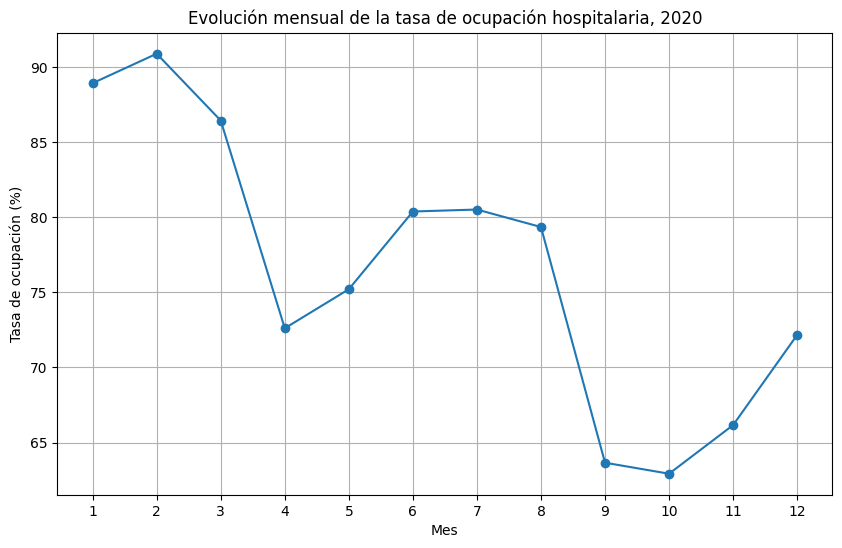

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    ocupacion_mes.index,
    ocupacion_mes['Tasa_Ocupacion'],
    marker='o'
)

plt.title('Evolución mensual de la tasa de ocupación hospitalaria, 2020')
plt.xlabel('Mes')
plt.ylabel('Tasa de ocupación (%)')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [ ]:
# Interpretación sencilla para la presentación

mes_mayor = ocupacion_mes['Tasa_Ocupacion'].idxmax()
valor_mayor = ocupacion_mes['Tasa_Ocupacion'].max()

print('El mes con mayor tasa de ocupación fue el mes', mes_mayor, 'con', round(valor_mayor, 2), '%')

El mes con mayor tasa de ocupación fue el mes 2 con 90.88 %


## Gráfica 2: carga asistencial mensual por egresos

Los egresos ayudan a ver en qué meses hubo mayor movimiento de pacientes. Para que el eje no se vea tan grande, se grafican en miles.

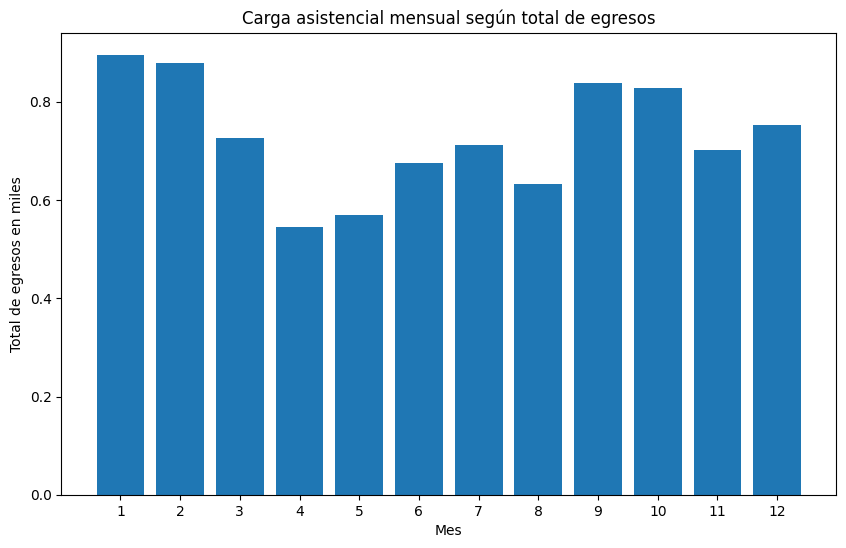

In [48]:
# Gráfica de carga asistencial mensual según total de egresos

plt.figure(figsize=(10, 6))

plt.bar(
    egresos_miles.index,
    egresos_miles.values
)

plt.title('Carga asistencial mensual según total de egresos')
plt.xlabel('Mes')
plt.ylabel('Total de egresos en miles')
plt.xticks(range(1, 13))

plt.show()

## Gráfica 3: servicios con mayor tasa de ocupación

Esta gráfica permite comparar qué grupos de servicio tuvieron mayor ocupación durante 2020.

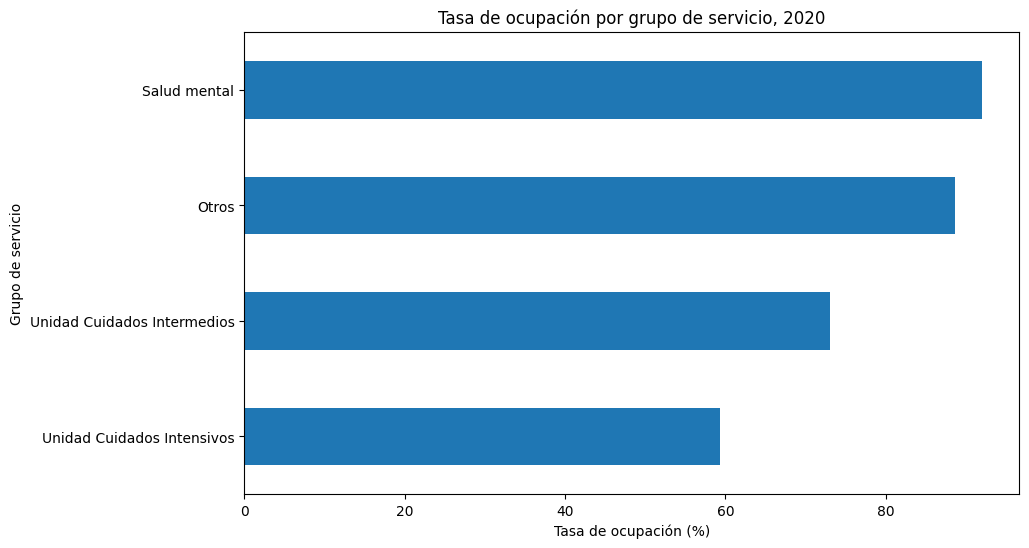

In [69]:
plt.figure(figsize=(10, 6))

ocupacion_servicio['Tasa_Ocupacion'].plot(kind='barh')

plt.title('Tasa de ocupación por grupo de servicio, 2020')
plt.xlabel('Tasa de ocupación (%)')
plt.ylabel('Grupo de servicio')
plt.gca().invert_yaxis()

plt.show()

In [ ]:
servicio_mayor = ocupacion_servicio.index[0]
valor_servicio_mayor = ocupacion_servicio['Tasa_Ocupacion'].iloc[0]

print('El grupo de servicio con mayor ocupación fue:', servicio_mayor)
print('Tasa de ocupación:', round(valor_servicio_mayor, 2), '%')

El grupo de servicio con mayor ocupación fue: Salud mental
Tasa de ocupación: 92.01 %


## Gráfica 4: mapa de calor de ocupación por mes y servicio

Esta es una de las gráficas más importantes, porque muestra qué servicios se vieron más ocupados en cada mes.

In [64]:
# Agrupamos por mes y grupo de servicio para calcular la ocupación de cada servicio en cada mes.

ocupacion_mes_servicio = df_graficas.groupby(['Mes', 'Grupo_Servicio'])[
    ['Dias_Cama_Ocupado', 'Dias_Cama_Disponible']
].sum()

# Calculamos la tasa de ocupación por mes y servicio

ocupacion_mes_servicio['Tasa_Ocupacion'] = (
    ocupacion_mes_servicio['Dias_Cama_Ocupado'] /
    ocupacion_mes_servicio['Dias_Cama_Disponible']
) * 100

ocupacion_mes_servicio.head()

Dias_Cama_Ocupado  Dias_Cama_Disponible  \
Mes Grupo_Servicio                                                         
1   Otros                                      498                   527   
    Salud mental                              3923                  4123   
    Unidad Cuidados Intensivos                1898                  2325   
    Unidad Cuidados Intermedios               1730                  2077   
2   Otros                                      455                   464   

                                 Tasa_Ocupacion  
Mes Grupo_Servicio                               
1   Otros                             94.497154  
    Salud mental                      95.149163  
    Unidad Cuidados Intensivos        81.634409  
    Unidad Cuidados Intermedios       83.293211  
2   Otros                             98.060345

In [65]:
# Convertimos la tabla en formato de matriz.
# Las filas serán los servicios y las columnas serán los meses.

tabla_mapa_calor = ocupacion_mes_servicio.pivot_table(
    values='Tasa_Ocupacion',
    index='Grupo_Servicio',
    columns='Mes'
)

tabla_mapa_calor

Mes,1,2,3,4,5,6,7,8,9,10,11,12
Grupo_Servicio,,,,,,,,,,,,
Otros,94.497154,98.060345,100.000000,97.843137,99.798387,97.058824,97.533207,90.752688,90.111111,76.548899,75.649718,92.489167
Salud mental,95.149163,96.264368,92.795699,90.303030,91.177908,92.061069,92.194041,91.212458,83.793103,87.828680,96.776860,93.602602
Unidad Cuidados Intensivos,81.634409,84.459770,80.555556,51.535581,51.008065,65.656566,74.236274,70.593027,48.267196,48.423893,49.001297,57.074926
Unidad Cuidados Intermedios,83.293211,85.960591,78.354371,58.697917,71.819842,73.765432,64.336918,79.928315,61.923077,62.519201,70.729167,69.026549


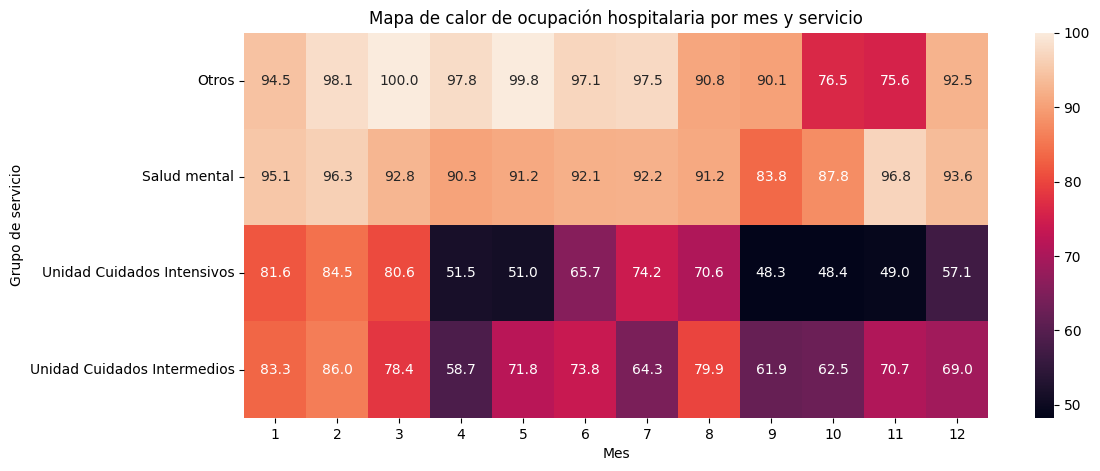

In [66]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    tabla_mapa_calor,
    annot=True,
    fmt='.1f'
)

plt.title('Mapa de calor de ocupación hospitalaria por mes y servicio')
plt.xlabel('Mes')
plt.ylabel('Grupo de servicio')

plt.show()

## Gráfica 5: camas disponibles vs días cama ocupados

Esta gráfica ayuda a ver la relación entre capacidad disponible y porcentaje de ocupación

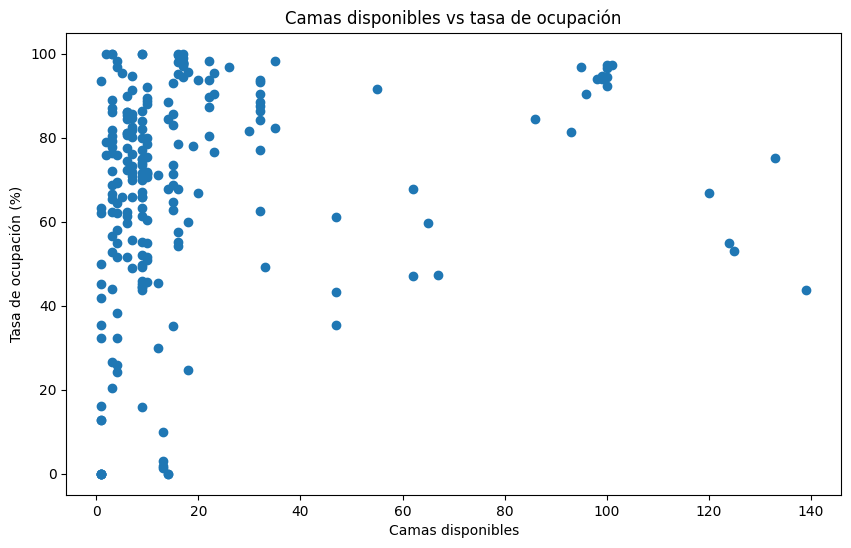

In [67]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_graficas['Camas_Disponibles'],
    df_graficas['Tasa_Ocupacion']
)

plt.title('Camas disponibles vs tasa de ocupación')
plt.xlabel('Camas disponibles')
plt.ylabel('Tasa de ocupación (%)')

plt.show()

In [68]:


df_limpio.to_excel('hospitalizacion_limpia.xlsx', index=False)

print('Archivo hospitalizacion_limpia.xlsx creado')

Archivo hospitalizacion_limpia.xlsx creado
